In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.db_utils import load_sql

sns.set_theme(style="whitegrid")

df = load_sql("SELECT * FROM documents")

print(f"Форма данных: {df.shape}")
print(f"Распределение по категориям:\n{df['category'].value_counts()}")

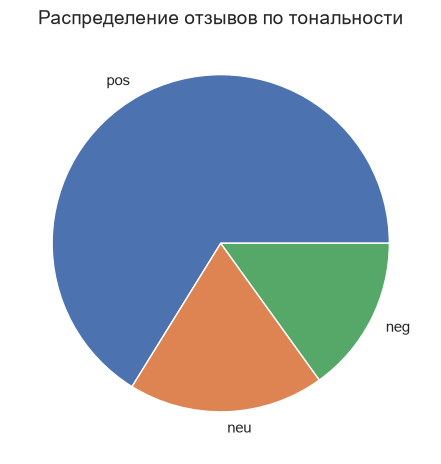

In [ ]:
counts = df['category'].value_counts()

counts.plot.pie()

plt.title('Распределение отзывов по тональности', fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
savePath = ('../data/processed/class_distribution.png')
plt.savefig(savePath, dpi=150)
plt.show()

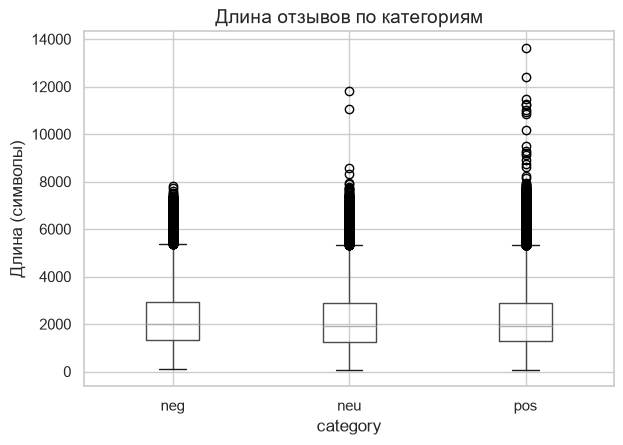


 Статистика длины:
            count         mean          std   min     25%     50%     75%  \
category                                                                    
neg       19827.0  2303.042013  1342.692025  98.0  1333.0  1982.0  2949.0   
neu       24704.0  2222.119616  1353.556938  58.0  1250.0  1917.0  2882.0   
pos       87138.0  2264.816762  1376.539551  62.0  1276.0  1925.0  2894.0   

              max  
category           
neg        7818.0  
neu       11807.0  
pos       13642.0  


In [ ]:
df['text_len'] = df['text'].str.len()

df.boxplot(column='text_len', by='category')

plt.suptitle('') 
plt.title('Длина отзывов по категориям', fontsize=14)
plt.ylabel('Длина (символы)')
plt.tight_layout()
plt.savefig(savePath, dpi=150)
plt.show()

print("\n Статистика длины:")
print(df.groupby('category')['text_len'].describe())

In [ ]:
import re
from collections import Counter

def get_words(text: str) -> list:
    text = text.lower()
    return re.findall(r'[а-яё]{3,}', text)

STOP_WORDS = {
    'это', 'что', 'как', 'все', 'так', 'для', 'но', 'да', 'не', 'на',
    'и', 'в', 'с', 'по', 'из', 'от', 'уже', 'был', 'была', 'фильм', 'фильма', 'его'
}

for cat in ['neg', 'neu','pos']:
    all_words = []
    for text in df[df['category'] == cat]['text']:
        all_words.extend(get_words(text))
    
    filtered_words = [w for w in all_words if w not in STOP_WORDS]
    top_words = Counter(filtered_words).most_common(10)
    
    print(f"\n{cat.upper()} - топ-10 слов:")
    for word, count in top_words:
        print(f"  {word}: {count}")


NEG - топ-10 слов:
  даже: 21141
  только: 20591
  если: 20180
  было: 19763
  просто: 18983
  очень: 17225
  нет: 16478
  или: 15141
  можно: 15122
  они: 15119

NEU - топ-10 слов:
  очень: 25029
  только: 21655
  даже: 21001
  если: 20964
  было: 19633
  или: 17796
  можно: 17499
  просто: 17474
  вот: 16684
  есть: 16475

POS - топ-10 слов:
  очень: 108476
  только: 76174
  даже: 69613
  просто: 68270
  она: 67123
  этот: 63175
  они: 62054
  если: 61707
  когда: 59651
  или: 59584
